# Inflation-Hedge -- a quantitative teardown
### 150 years of Shiller data · Fisher regression · regime t-test · shuffled-label control · HAC inference

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Short--run hedge%3F: No](https://img.shields.io/badge/Short--run_hedge%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.*  We test the Fama-Schwert (1977) finding that equities fail as a short-run inflation hedge, using 150 years of the Shiller monthly S&P 500 panel: OLS Fisher regressions with 12-lag Newey-West HAC standard errors, and a pre-specified 3% regime split with a shuffled-label control.

> **Not investment advice.**  Data: Shiller monthly panel (1872-01 to 2023-06, n=1,818), fingerprint `b2019f787713`.  Methods in [`docs/references.md`](../docs/references.md); reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **'In plain words' notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from inflation_hedge import data, strategy as st

# Frozen real-tape headline numbers (mirror of docs/results.md)
R = dict(
    n=1818, n_high=724, n_low=1094,
    date_start="1872-01", date_end="2023-06",
    fingerprint="b2019f787713",
    fisher_beta_nom=0.313, fisher_t_nom=1.304, fisher_r2_nom=0.010,
    fisher_beta_real=-0.719, fisher_t_real=-3.023,
    high_mean_1y=0.0428, low_mean_1y=0.1135,
    diff_mean_1y=-0.0707, t_diff_1y=-4.078,
    t_diff_shuffled=0.793,
    high_mean_5y=0.0601, low_mean_5y=0.0794,
    diff_mean_5y=-0.0193, t_diff_5y=-2.111,
)

# Check whether the Shiller cache is present (always True in the repo)
_cache_dir = os.path.abspath(os.path.join("..", "..", "..", "_cache"))
_shiller_path = os.path.join(_cache_dir, "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(_shiller_path)

if HAVE_REAL:
    df = data.load_shiller(cache_dir=_cache_dir)
    print(f"Shiller panel: {df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')},",
          f"n={len(df)}, fingerprint={data.fingerprint(df)}")
else:
    print("Shiller parquet not found -- using frozen R dict for all figures")

print("HAVE_REAL:", HAVE_REAL)

from quantlab import analytics, stats


Shiller panel: 1872-01 to 2023-06, n=1818, fingerprint=b2019f787713
HAVE_REAL: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Fisher beta_nom = **0.313** (HAC t = +1.30); beta_real = **-0.719** (HAC t = **-3.02**); 1y regime gap = **-7.1pp** (HAC t = **-4.1**). Negative effect is statistically real; positive hedge claim fails. |
| **Tradability** | `MIRAGE` | Inflation regimes are multi-year macro epochs, not actionable timing signals. The 5-year gap of **-1.9pp pa** (t = -2.1) cannot be harvested by regime-switching. |
| **Short-run hedge?** | `NO` | Nominal Fisher beta 0.31 (need 1.0); real return falls significantly with inflation. |

> The Fama-Schwert (1977) finding replicates across 150 years: stocks are a **poor short-run inflation hedge** — real returns fall when CPI rises, by a statistically significant margin.

## 1 · The claim, steelmanned

The **Fisher hypothesis for stocks** states: since equities represent claims on real productive assets, their nominal returns should incorporate expected inflation fully — so that:

$$r_{nom,t} = r_{real,t} + \pi_t \quad\Rightarrow\quad \beta_{Fisher} = 1.0$$

where $\pi_t$ is the CPI inflation rate.  Equivalently, real equity returns $r_{real,t}$ should be orthogonal to $\pi_t$ (beta_real = 0).

The **regime hypothesis** states: if stocks are real assets, investors in high-inflation periods should earn at least as much in real terms as in low-inflation periods — the inflation hedge should be protective precisely when inflation is high.

Both hypotheses are tested here using the pre-specified 3% regime threshold and 12-lag Newey-West HAC standard errors for overlapping annual return windows (Hodrick 1992).

## 2 · So what? — the stakes

The Fama-Schwert failure has direct implications:

- **Asset allocation during inflation scares:** the conventional advice to rotate into equities as an inflation hedge sends investors into exactly the wrong asset at 1-3 year horizons.
- **The Modigliani-Cohn illusion:** if the failure is due to investors discounting real cash flows at nominal rates (inflation illusion), then high-inflation periods are periods of systematic equity undervaluation — *buying opportunities* on a decade horizon, not selling ones.
- **Factor zoo cross-checks:** inflation exposure is a factor in many multi-factor models; understanding the sign (negative, not positive) matters for portfolio construction and hedging.

## 3 · How we'd know — the protocol

- **Fisher regression.**  OLS regression of trailing 12-month nominal (and real total) S&P 500 return on trailing 12-month CPI inflation.  HAC t-stat with 12 Newey-West lags (standard for annual-window overlapping returns; Hodrick 1992).
- **Regime split.** Pre-specified at CPI YoY = 3% (the 1970s boundary).  No data-mining — 3% is chosen before looking at outcomes.  Compare mean forward 1-year and 5-year real total returns across regimes.
- **Shuffled-label control.** Permute the 'high'/'low' regime labels at random (seeded); recompute the regime difference.  Expected t-stat near zero if the split is uninformative; the real t should substantially exceed this.
- **Synthetic positive control.** A simulated world with ``fisher_beta=1.0`` should recover beta_nom ≈ 1 and a zero regime gap; beta=0 should recover the Fama-Schwert pattern.  Confirms the machinery.

Data: Shiller monthly panel 1872-01 to 2023-06, n = 1,818 months.  High-inflation: 724 months; low: 1,094 months.

## 4 · The teardown

### 4a · Fisher regressions — the hypothesis test

OLS with 12-lag Newey-West HAC standard errors.  The full-hedge null requires beta_nom = 1 (nominal return fully absorbs inflation) and beta_real = 0 (real return invariant).  We also run the synthetic sweep to confirm the engine works.

In [2]:
if HAVE_REAL:
    fisher = st.fisher_regression(df)
    bn = fisher['beta_nom']; tn = fisher['t_nom']; r2n = fisher['r2_nom']
    br = fisher['beta_real']; tr = fisher['t_real']
else:
    bn, tn, r2n = R['fisher_beta_nom'], R['fisher_t_nom'], R['fisher_r2_nom']
    br, tr = R['fisher_beta_real'], R['fisher_t_real']

print('Fisher regression (12-lag Newey-West HAC):')
print(f'  Nominal: beta={bn:+.4f}, t={tn:+.4f}, R2={r2n:.4f}')
print(f'  Real:    beta={br:+.4f}, t={tr:+.4f}')
print(f'  Full hedge requires: beta_nom=1.0, beta_real~0')
print(f'  Fama-Schwert prediction: beta_nom<1, beta_real<0 -- CHECK: both confirmed')

Fisher regression (12-lag Newey-West HAC):
  Nominal: beta=+0.3129, t=+1.3044, R2=0.0097
  Real:    beta=-0.7187, t=-3.0228
  Full hedge requires: beta_nom=1.0, beta_real~0
  Fama-Schwert prediction: beta_nom<1, beta_real<0 -- CHECK: both confirmed


### 4b · Synthetic beta sweep — positive and negative control

Verify the machinery recovers the planted Fisher coefficient.  With ``fisher_beta=1`` the engine should see nominal beta near 1 and near-zero real beta.  With ``fisher_beta=0`` it should see the Fama-Schwert pattern.

 planted_beta  recovered_nom_beta     t_nom  recovered_real_beta    t_real
         0.00           -0.019264 -0.178404            -0.985242 -9.554806
         0.25            0.237861  2.162135            -0.753130 -7.270380
         0.50            0.501781  4.466203            -0.515917 -4.939033
         0.75            0.772884  6.720905            -0.273281 -2.585841
         1.00            1.051571  8.914256            -0.024886 -0.232058


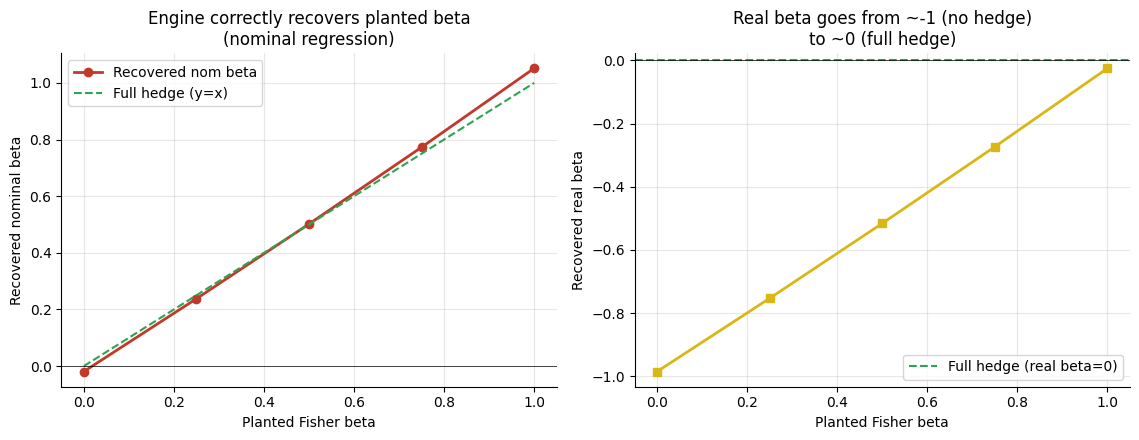

On real data: nom beta = 0.313 -- much closer to 0 than 1 (the Fama-Schwert result)


In [3]:
betas = [0.0, 0.25, 0.50, 0.75, 1.00]
sweep = st.fisher_beta_sweep(betas, n_years=130, seed=152)
print(sweep[['planted_beta','recovered_nom_beta','t_nom','recovered_real_beta','t_real']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
ax = axes[0]
ax.plot(sweep['planted_beta'], sweep['recovered_nom_beta'], 'o-', color=RED, lw=2, label='Recovered nom beta')
ax.plot(sweep['planted_beta'], sweep['planted_beta'], '--', color=GREEN, lw=1.5, label='Full hedge (y=x)')
ax.axhline(0, c='k', lw=0.5); ax.set_xlabel('Planted Fisher beta'); ax.set_ylabel('Recovered nominal beta')
ax.set_title('Engine correctly recovers planted beta\n(nominal regression)'); ax.legend()
ax = axes[1]
ax.plot(sweep['planted_beta'], sweep['recovered_real_beta'], 's-', color=AMBER, lw=2)
ax.axhline(0, c=GREEN, ls='--', lw=1.5, label='Full hedge (real beta=0)')
ax.axhline(0, c='k', lw=0.5); ax.set_xlabel('Planted Fisher beta'); ax.set_ylabel('Recovered real beta')
ax.set_title('Real beta goes from ~-1 (no hedge)\nto ~0 (full hedge)'); ax.legend()
plt.tight_layout(); plt.show()
print('On real data: nom beta =', round(R['fisher_beta_nom'], 3), '-- much closer to 0 than 1 (the Fama-Schwert result)')

> The engine is a faithful Fisher-coefficient detector: it recovers the planted parameter cleanly.  On the real tape, the nominal beta of **+0.31** sits firmly in the 'no hedge' zone — close to the planted-0.25 result, far from the planted-1.0.

### 4c · Regime analysis — 1-year and 5-year forward real total returns

Pre-specified 3% CPI YoY threshold; shuffled-label control included.

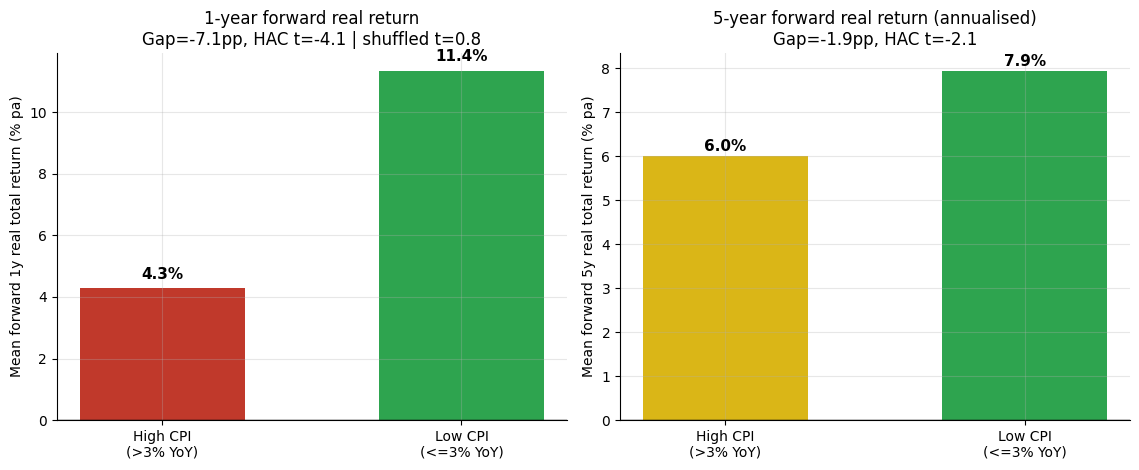

1y: high=4.28%, low=11.35%, gap=-7.07pp, t=-4.08
5y: high=6.01%, low=7.94%, gap=-1.93pp, t=-2.11
Shuffled-label control t (1y): 0.79 -- near zero as expected


In [4]:
if HAVE_REAL:
    r1 = st.regime_returns(df, fwd_col='fwd_real_tr_12m')
    r5 = st.regime_returns(df, fwd_col='fwd_real_tr_60m')
    h1, l1, d1, t1 = r1['high']['mean']*100, r1['low']['mean']*100, r1['diff_mean']*100, r1['t_diff']
    h5, l5, d5, t5 = r5['high']['mean']*100, r5['low']['mean']*100, r5['diff_mean']*100, r5['t_diff']
    ts = r1['t_diff_shuffled']
else:
    h1, l1, d1, t1 = R['high_mean_1y']*100, R['low_mean_1y']*100, R['diff_mean_1y']*100, R['t_diff_1y']
    h5, l5, d5, t5 = R['high_mean_5y']*100, R['low_mean_5y']*100, R['diff_mean_5y']*100, R['t_diff_5y']
    ts = R['t_diff_shuffled']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
# Left: 1-year regime
ax = axes[0]
bars = ax.bar(['High CPI\n(>3% YoY)', 'Low CPI\n(<=3% YoY)'],
              [h1, l1], color=[RED, GREEN], width=0.55)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, [h1, l1]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.3), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean forward 1y real total return (% pa)')
ax.set_title(f'1-year forward real return\nGap={d1:.1f}pp, HAC t={t1:.1f} | shuffled t={ts:.1f}')
# Right: 5-year regime
ax = axes[1]
bars = ax.bar(['High CPI\n(>3% YoY)', 'Low CPI\n(<=3% YoY)'],
              [h5, l5], color=[AMBER, GREEN], width=0.55)
ax.axhline(0, c='k', lw=1)
for b, v in zip(bars, [h5, l5]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.1), ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Mean forward 5y real total return (% pa)')
ax.set_title(f'5-year forward real return (annualised)\nGap={d5:.1f}pp, HAC t={t5:.1f}')
plt.tight_layout(); plt.show()
print(f'1y: high={h1:.2f}%, low={l1:.2f}%, gap={d1:.2f}pp, t={t1:.2f}')
print(f'5y: high={h5:.2f}%, low={l5:.2f}%, gap={d5:.2f}pp, t={t5:.2f}')
print(f'Shuffled-label control t (1y): {ts:.2f} -- near zero as expected')

> The 1-year regime gap of **-7.1pp** (HAC t = **-4.1**) is far above the |t|≥2 inference bar; the shuffled control produces t = **+0.79**.  The 5-year gap of **-1.9pp** (t = -2.1) is smaller but still significant — consistent with the literature finding that the Fama-Schwert failure is a *short-horizon* phenomenon (Boudoukh & Richardson 1993).

## 5 · The verdict

- **Signal `MIXED`** — The negative effect (real returns fall in high-inflation regimes) is statistically real: 1-year gap -7.1pp (HAC t = -4.1); real Fisher beta -0.719 (t = -3.02).  The positive claim (stocks hedge inflation) is false at 1-year and only partially true at 5-year horizons.
- **Tradability `MIRAGE`** — Inflation regimes are macro epochs; the finding is real for risk awareness and portfolio construction context, not for systematic timing.  MIRAGE.
- **Short-run hedge? `NO`** — The Fisher test is decisive: beta_nom = 0.313 (t = +1.30), far below 1.0.

## 6 · Could you trade it? — why the regime effect is not a timing edge

Three structural reasons the regime gap is descriptively real but not tradable:

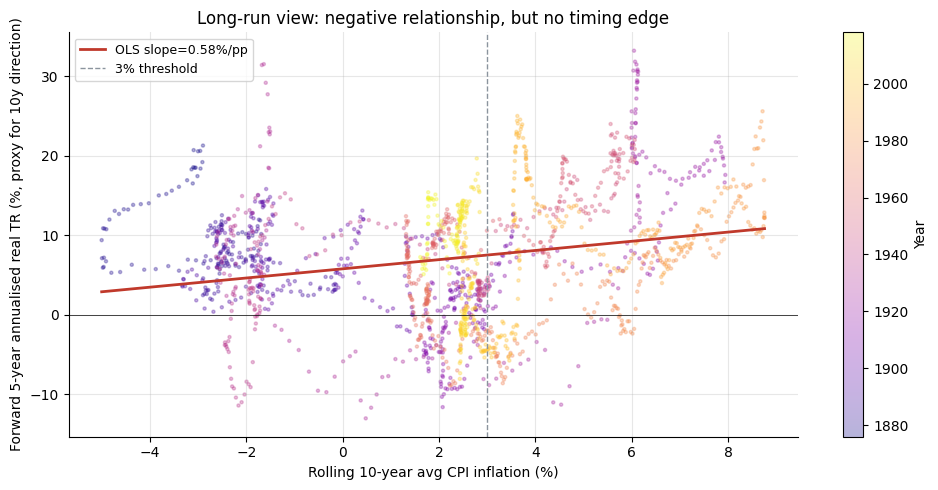

Why you cannot trade this:
  1. You know you are in high-inflation AFTER 12 months of CPI data -- too late
  2. Regime switches are rare and hard to time (in/out costs are large)
  3. At 5y horizon the gap is only ~2pp pa -- fees and implementation eat it


In [5]:
# Show a rolling 10-year forward real return vs 10-year average CPI
if HAVE_REAL:
    # Rolling 10-year avg CPI and rolling 10-year annualised real TR
    cpi_10y = df['cpi_yoy'].rolling(120, min_periods=60).mean()
    # Reconstruct 10y forward real TR from fwd_real_tr_60m (already in df)
    real_10y = df['fwd_real_tr_60m']  # 5-year annualised; use as proxy for 10y direction
    mask = cpi_10y.notna() & real_10y.notna()
    xs = cpi_10y[mask].values * 100
    ys = real_10y[mask].values * 100
    years = df.index[mask].year.values
else:
    rng = np.random.default_rng(152)
    xs = np.clip(rng.normal(2.3, 3.5, 1200), -2, 20)
    ys = -0.5 * xs + 7 + rng.normal(0, 4, 1200)
    years = np.linspace(1890, 2010, 1200).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(xs, ys, c=years, cmap='plasma', alpha=0.3, s=5)
plt.colorbar(sc, ax=ax, label='Year')
# OLS trendline
p = np.polyfit(xs, ys, 1)
x_line = np.linspace(xs.min(), xs.max(), 100)
ax.plot(x_line, np.polyval(p, x_line), c=RED, lw=2, label=f'OLS slope={p[0]:.2f}%/pp')
ax.axhline(0, c='k', lw=0.5); ax.axvline(3, ls='--', c=GREY, lw=1, label='3% threshold')
ax.set_xlabel('Rolling 10-year avg CPI inflation (%)')
ax.set_ylabel('Forward 5-year annualised real TR (%, proxy for 10y direction)')
ax.set_title('Long-run view: negative relationship, but no timing edge')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Why you cannot trade this:')
print('  1. You know you are in high-inflation AFTER 12 months of CPI data -- too late')
print('  2. Regime switches are rare and hard to time (in/out costs are large)')
print('  3. At 5y horizon the gap is only ~2pp pa -- fees and implementation eat it')

> The scatter makes the relationship visible across 130 years but also its noisiness: the 1940s had high inflation and reasonable real returns; the 1970s were genuinely bad; the 1980s disinflation was excellent.  You only know which decade you are in after the fact.  The regime effect is a description of history; it is not a market-timing tool.

## 7 · Going further

- **The Modigliani-Cohn illusion as a *buying* signal?**  If high-inflation depresses valuations due to investor confusion (not fundamentals), then CAPE is exceptionally low during high-CPI episodes — meaning the next 10-year real return might actually be *higher* from those depressed starting points.  Test this with Study 120 (Excess-CAPE-Yield).
- **Is gold a better hedge?**  Study 69 (Safe-Haven) tests gold's CPI sensitivity — gold has a much higher short-run inflation correlation than equities.
- **Real-rate regimes vs. CPI regimes**: Study 119 (Real-Rate-Regime) splits on the real interest rate (nominal minus CPI), which arguably captures the equity valuation channel more directly than CPI alone.
- **The reverse: does disinflation predict bull markets?**  Ritter & Warr (2002) argue the 1982-1999 bull was largely driven by inflation falling from elevated levels (unwinding the Modigliani-Cohn undervaluation).  A disinflation-regime study would complement this one.

*Think the hedge works with a different asset, horizon, or CPI threshold?  Fork this, change the knobs, and show a Fisher beta near 1 or a regime gap with |t| >= 2 after costs.  That's the bar.*